In [1]:
import os
# Mute OpenCV warnings BEFORE importing cv2
os.environ["OPENCV_LOG_LEVEL"] = "FATAL" 

!pip install -q albumentations

import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Set device to GPU if available in Kaggle
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Dataset Loading
We redefine our dataset splitting and loading logic from the data exploration phase. This ensures our baseline is evaluated on the exact same train/validation splits that our advanced model will use.

In [2]:
# 1. Dynamically locate the dataset
image_search_paths = glob.glob('/kaggle/input/**/train/images/*', recursive=True)
train_dir = os.path.dirname(os.path.dirname(image_search_paths[0]))
IMAGE_DIR = os.path.join(train_dir, 'images')
MASK_DIR = os.path.join(train_dir, 'gt')
ext = os.path.splitext(image_search_paths[0])[1]

cities = ['austin', 'chicago', 'kitsap', 'tyrol-w', 'vienna']
train_imgs, train_masks = [], []
val_imgs, val_masks = [], []

# 2. Re-create the Train and Validation splits
for city in cities:
    for i in range(1, 31): # Only loading train and val for this phase
        img_name = f"{city}{i}{ext}"
        img_path = os.path.join(IMAGE_DIR, img_name)
        mask_path = os.path.join(MASK_DIR, img_name)
        
        if os.path.exists(img_path) and os.path.exists(mask_path):
            if i <= 25:
                train_imgs.append(img_path)
                train_masks.append(mask_path)
            elif i <= 30:
                val_imgs.append(img_path)
                val_masks.append(mask_path)

# 3. Define Dataset Class
class InriaPatchDataset(Dataset):
    def __init__(self, image_paths, mask_paths, patch_size=256, stride=256):
        self.patch_size = patch_size
        self.stride = stride
        self.samples = []
        for img_p, msk_p in zip(image_paths, mask_paths):
            for y in range(0, 5000 - patch_size + 1, stride):
                for x in range(0, 5000 - patch_size + 1, stride):
                    self.samples.append((img_p, msk_p, x, y))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, msk_path, x, y = self.samples[idx]
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        patch_img = img[y:y+self.patch_size, x:x+self.patch_size]

        mask = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)
        patch_mask = mask[y:y+self.patch_size, x:x+self.patch_size]
        patch_mask = (patch_mask > 128).astype(np.float32)

        patch_img = ToTensorV2()(image=patch_img)['image'].float() / 255.0
        patch_mask = torch.tensor(patch_mask, dtype=torch.float32).unsqueeze(0)
        return patch_img, patch_mask

# Create DataLoaders (using smaller patches for the baseline to speed up training)
train_dataset = InriaPatchDataset(train_imgs, train_masks, patch_size=256, stride=256)
val_dataset = InriaPatchDataset(val_imgs, val_masks, patch_size=256, stride=256)

# Limit dataset size slightly for the baseline to ensure rapid prototyping
subset_indices_train = torch.randperm(len(train_dataset))[:2000]
subset_indices_val = torch.randperm(len(val_dataset))[:500]

train_subset = torch.utils.data.Subset(train_dataset, subset_indices_train)
val_subset = torch.utils.data.Subset(val_dataset, subset_indices_val)

train_loader = DataLoader(train_subset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=16, shuffle=False, num_workers=2)

print(f"Training batches: {len(train_loader)} | Validation batches: {len(val_loader)}")

Training batches: 125 | Validation batches: 32


## Simple CNN Baseline Architecture
The specification states we must include a simple baseline[cite: 1]. We define a very lightweight Convolutional Neural Network with a basic downsampling and upsampling path. This model lacks skip connections and complex feature extraction, serving as a lower bound for our evaluation metrics.

In [3]:
class SimpleBaselineCNN(nn.Module):
    def __init__(self):
        super(SimpleBaselineCNN, self).__init__()
        # Simple Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        
        # Simple Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(16, 8, kernel_size=2, stride=2),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(8, 1, kernel_size=1)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

def compute_metrics(pred_mask, true_mask, threshold=0.5, eps=1e-7):
    """Computes IoU and Dice Coefficient[cite: 1]"""
    pred = (pred_mask > threshold).float()
    true = (true_mask > threshold).float()
    
    intersection = (pred * true).sum()
    union = pred.sum() + true.sum() - intersection
    
    iou = (intersection + eps) / (union + eps)
    dice = (2.0 * intersection + eps) / (pred.sum() + true.sum() + eps)
    return iou.item(), dice.item()

model = SimpleBaselineCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

## Training the Baseline
We will train this baseline model for a minimal number of epochs (e.g., 5 epochs) just to establish our initial weights and confirm our training loop, loss calculation, and metric evaluations function correctly end-to-end.

In [5]:
num_epochs = 5
history = {'train_loss': [], 'val_iou': [], 'val_dice': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    epoch_loss = running_loss / len(train_loader)
    history['train_loss'].append(epoch_loss)
    
    # Validation Phase
    model.eval()
    val_iou_list, val_dice_list = [], []
    
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = torch.sigmoid(outputs)
            
            iou, dice = compute_metrics(preds, masks)
            val_iou_list.append(iou)
            val_dice_list.append(dice)
            
    avg_iou = np.mean(val_iou_list)
    avg_dice = np.mean(val_dice_list)
    
    history['val_iou'].append(avg_iou)
    history['val_dice'].append(avg_dice)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {epoch_loss:.4f} | Val IoU: {avg_iou:.4f} | Val Dice: {avg_dice:.4f}")

# Save baseline model weights locally to Kaggle output
torch.save(model.state_dict(), '/kaggle/working/baseline_cnn.pth')
print("Baseline model saved.")

Epoch [1/5] | Loss: 0.3623 | Val IoU: 0.1187 | Val Dice: 0.2063
Epoch [2/5] | Loss: 0.3592 | Val IoU: 0.1768 | Val Dice: 0.2928
Epoch [3/5] | Loss: 0.3556 | Val IoU: 0.1445 | Val Dice: 0.2456
Epoch [4/5] | Loss: 0.3552 | Val IoU: 0.1955 | Val Dice: 0.3194
Epoch [5/5] | Loss: 0.3534 | Val IoU: 0.1288 | Val Dice: 0.2219
Baseline model saved.


## Qualitative Output Evaluation
For our checkpoint review and final report, we must present qualitative visual evidence and analyze failure cases[cite: 1]. Let's extract a few predictions from our validation set to visualize how our baseline model is performing.

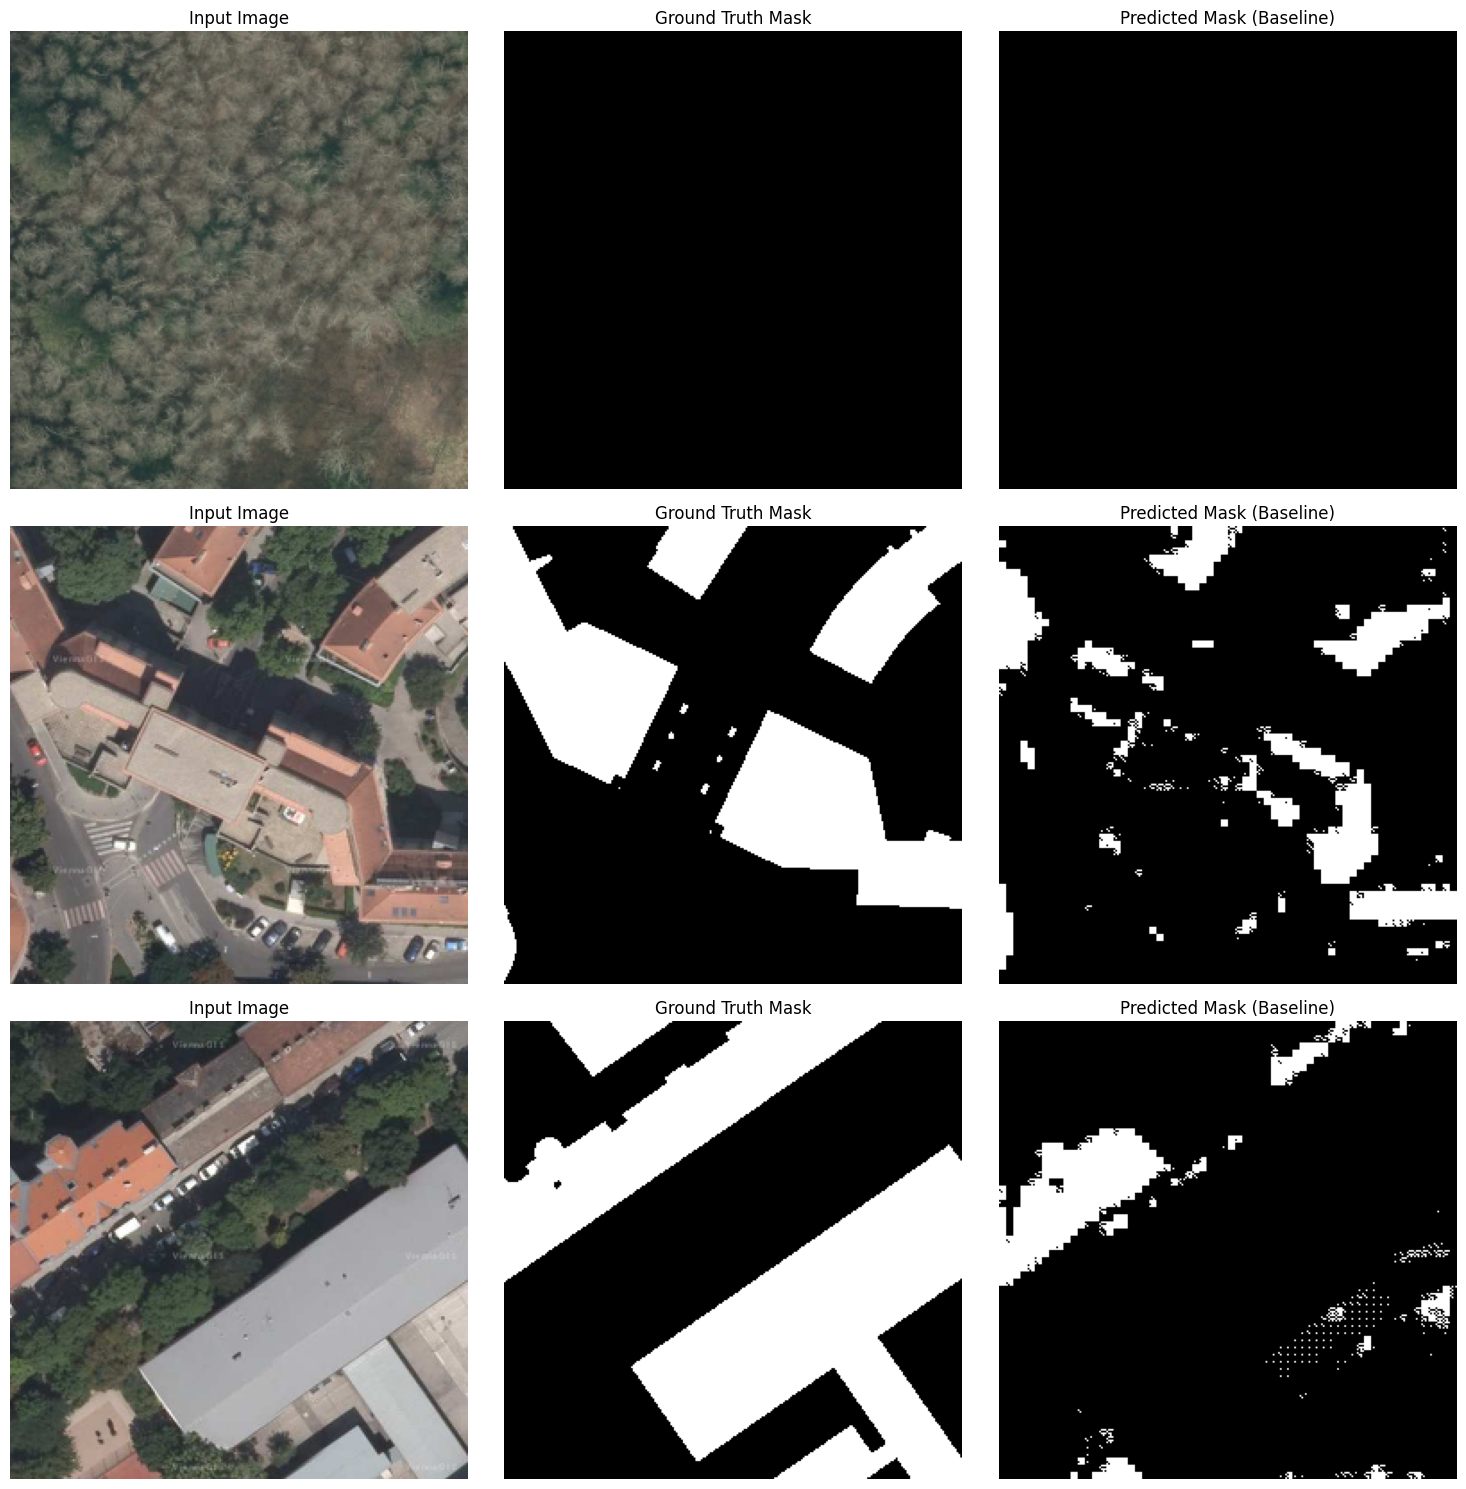

In [6]:
def visualize_baseline_predictions(model, dataloader, num_samples=3):
    model.eval()
    images_shown = 0
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    
    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.sigmoid(outputs).cpu()
            
            for i in range(images.size(0)):
                if images_shown >= num_samples:
                    break
                    
                # Convert formats for plotting
                img_np = images[i].cpu().permute(1, 2, 0).numpy()
                true_mask_np = masks[i].squeeze(0).numpy()
                pred_mask_np = (preds[i].squeeze(0).numpy() > 0.5).astype(np.float32)
                
                axes[images_shown, 0].imshow(img_np)
                axes[images_shown, 0].set_title("Input Image")
                axes[images_shown, 0].axis("off")
                
                axes[images_shown, 1].imshow(true_mask_np, cmap="gray")
                axes[images_shown, 1].set_title("Ground Truth Mask")
                axes[images_shown, 1].axis("off")
                
                axes[images_shown, 2].imshow(pred_mask_np, cmap="gray")
                axes[images_shown, 2].set_title("Predicted Mask (Baseline)")
                axes[images_shown, 2].axis("off")
                
                images_shown += 1
                
            if images_shown >= num_samples:
                break
                
    plt.tight_layout()
    plt.show()

# Run visualization on the validation set
visualize_baseline_predictions(model, val_loader, num_samples=3)